In [7]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import warnings
from statsmodels.tsa.statespace.varmax import VARMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.tsa.stattools import adfuller

In [3]:
warnings.filterwarnings("ignore")  # ignorer les warning qui sont fréquents en VARMA

def auto_VARMAX_model(y_train, X_train=None, max_p=2, max_q=1, test_y=False, test_X=False):
     
    best_aic = float("inf")
    best_order = (0, 0)
    best_fit = None

    # Grid Search : on teste toutes les combinaisons (p, q)
    for p in range(max_p + 1):
        for q in range(max_q + 1):
            if p == 0 and q == 0: 
                continue 
            
            try:
                # Tentative d'entraînement
                model = VARMAX(y_train, exog=X_train, order=(p, q), enforce_stationarity=True)
                results = model.fit(disp=False)

                if results.aic < best_aic:
                    best_aic = results.aic
                    best_order = (p, q)
                    best_fit = results
            except:
                continue # Si erreur mathématique ou de convergence, on passe silencieusement au suivant dans la boucle

    # Évaluation sur le set de test
    if test_y is not False:
        n_test = len(test_y)
        predictions = best_fit.forecast(steps=n_test, exog=test_X)

        rmse = np.sqrt(mean_squared_error(test_y, predictions))
        mae = mean_absolute_error(test_y, predictions)
        
        return {
            'modele_fit': best_fit, 
            'best_order': best_order,
            'predictions': predictions, 
            'rmse': rmse, 
            'mae': mae
        }

    return {'modele_fit': best_fit, 'best_order': best_order}

## Application

## VARMA

In [8]:
# Chargement dataset
def load_wadi_data():
    path = input("Veuillez entrer le chemin complet du fichier CSV : ")
    if os.path.exists(path):
        df = pd.read_csv(path)
        print(f"Base chargée : {df.shape[0]} lignes, {df.shape[1]} colonnes.")
        return df
    else:
        print("Chemin invalide.")
        return None

df = load_wadi_data()

Veuillez entrer le chemin complet du fichier CSV :  C:/Users/abmahamat/Downloads/WADI_clean.csv


Base chargée : 204116 lignes, 124 colonnes.


In [15]:
target_cols = [
    "3_LT_001_PV",
    "1_LT_001_PV",
    "2_LT_001_PV",
    "2_LT_002_PV"
]

y = df[target_cols]

In [16]:
# y contient uniquement les 4 variables à prédire
y = df[target_cols].copy()

train_frac = 0.7
test_frac = 0.15

n_total = len(y)
train_end = int(n_total * train_frac)

y_train = y.iloc[:train_end]
y_test  = y.iloc[train_end:]

In [17]:
result_varma = auto_VARMAX_model(
    y_train=y_train,
    X_train=None,
    max_p=2,
    max_q=1,
    test_y=y_test,
    test_X=None
)

print("Meilleur ordre VARMA :", result_varma["best_order"])
print("RMSE :", result_varma["rmse"])
print("MAE :", result_varma["mae"])

Meilleur ordre VARMA : (2, 1)
RMSE : 4.934331180409165
MAE : 3.0612976414982076


In [20]:
rmse_arima = 1.5186
rmse_varma = 4.9343
skill_score = 1 - (rmse_varma / rmse_arima)
print(f"skill score = {skill_score}")

skill score = -2.249242723561175


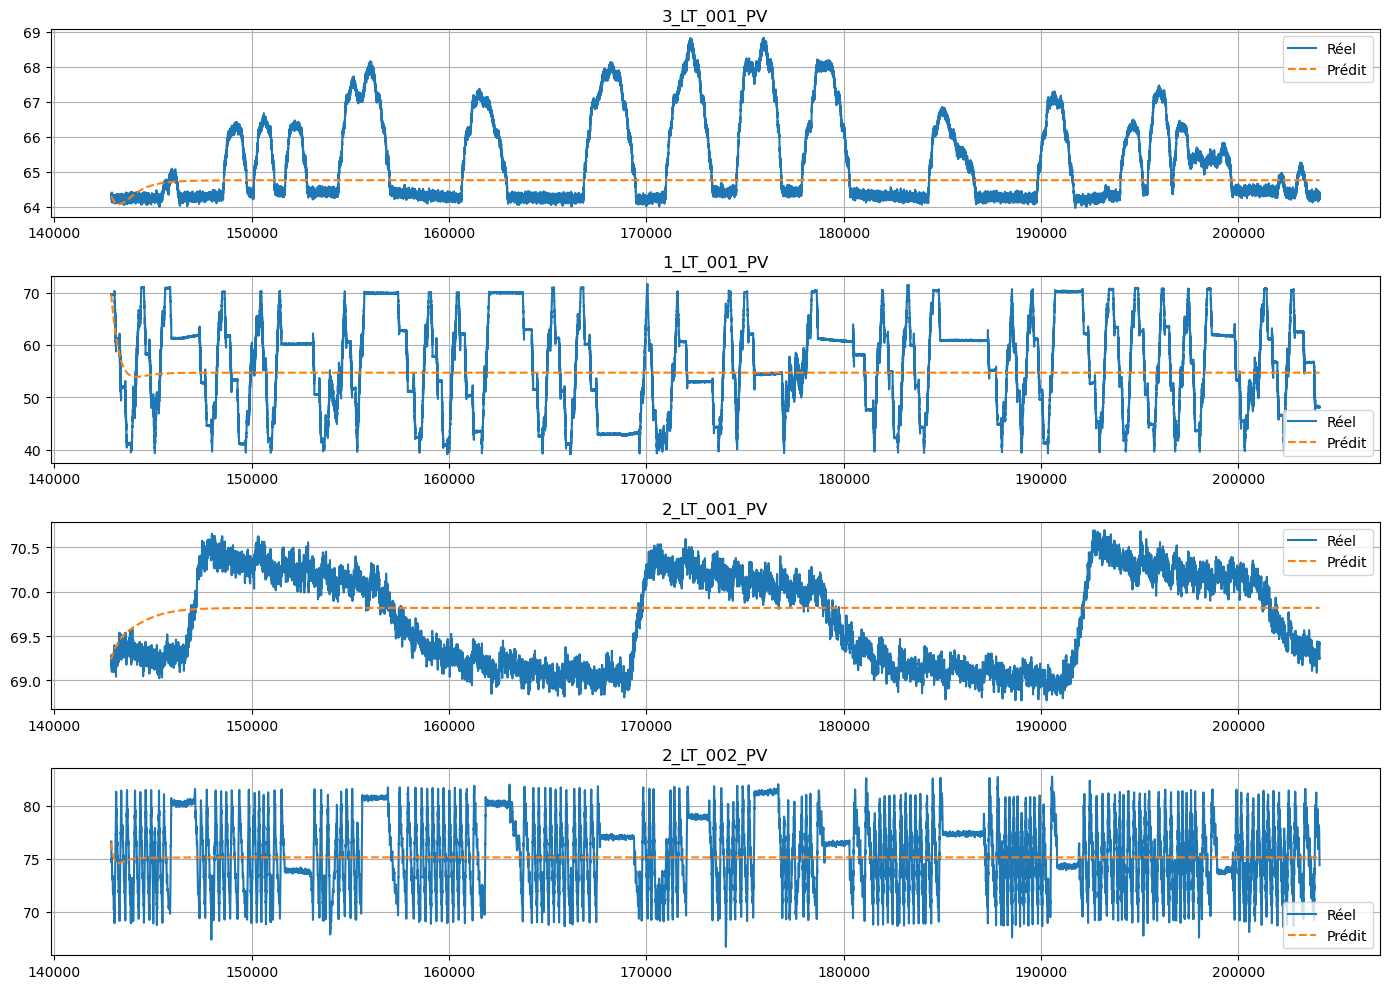

In [21]:
cols = y_test.columns

plt.figure(figsize=(14,10))

for i, col in enumerate(cols):
    plt.subplot(len(cols), 1, i+1)

    plt.plot(y_test.index, y_test[col], label="Réel")
    plt.plot(y_test.index, result_varma["predictions"][col],
             label="Prédit", linestyle="--")

    plt.title(col)
    plt.legend()
    plt.grid()

plt.tight_layout()
plt.savefig("varma_predictions.png")
plt.show()

In [22]:
def skill_score_varma(y_true, y_pred, baseline_pred=None):
    """
    Skill score VARMA vs baseline naïf persistant.

    Baseline :
    y_hat(t) = y(t-1)

    Fonction adaptée aux prédictions multivariées.
    """

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # baseline naïf multivarié
    if baseline_pred is None:
        baseline_pred = np.roll(y_true, 1, axis=0)
        baseline_pred[0, :] = y_true[0, :]
    else:
        baseline_pred = np.array(baseline_pred)

    rmse_model = np.sqrt(mean_squared_error(y_true, y_pred))
    rmse_base = np.sqrt(mean_squared_error(y_true, baseline_pred))

    return 1 - (rmse_model / (rmse_base + 1e-8))

In [26]:
def skill_score_gru(y_true, y_pred, baseline_pred=None):
    """
    Skill score du modèle GRU par rapport à un baseline naïf persistant.

    Baseline naïf :
    y_hat(t) = y(t-1)

    SS = 1 - RMSE_model / RMSE_baseline
    """

    y_true = np.array(y_true).reshape(-1)
    y_pred = np.array(y_pred).reshape(-1)

    # baseline naïf si non fourni
    if baseline_pred is None:
        baseline_pred = np.roll(y_true, 1)
        baseline_pred[0] = y_true[0]
    else:
        baseline_pred = np.array(baseline_pred).reshape(-1)

    rmse_model = np.sqrt(mean_squared_error(y_true, y_pred))
    rmse_base = np.sqrt(mean_squared_error(y_true, baseline_pred))

    return 1 - (rmse_model / (rmse_base + 1e-8))

In [27]:
y_true = y_test.values
y_pred = result_varma["predictions"].values

ss_varma = skill_score_varma(y_true, y_pred)

print("Skill Score VARMA :", ss_varma)

Skill Score VARMA : -22.048753226205033


In [28]:
for col in y_test.columns:
    ss = skill_score_gru(
        y_true=y_test[col].values,
        y_pred=result_varma["predictions"][col].values
    )
    print(col, ":", ss)

3_LT_001_PV : -24.952124458905
1_LT_001_PV : -23.91324526045979
2_LT_001_PV : -19.36541657511098
2_LT_002_PV : -15.077386410641427
